In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [ ]:
def load_data(filename):
  return pd.read_csv('https://raw.githubusercontent.com/huynhhoc/DataAnalystDeepLearning/main/Data/'+filename)

df = load_data("23_HOMES.csv")
df.head()

,Selling_Price,List_Price,Area,Acres,Age,Taxes,Rooms,Bedrooms,Baths_full
0,400000,414000,2704,2.27,27,4920,9,3,3
1,370000,379000,2096,0.75,21,4113,8,4,2
2,382500,389900,2737,1.00,36,6072,9,4,2
3,300000,299900,1800,0.43,34,4024,8,4,2
4,305000,319900,1066,3.60,69,3562,6,3,2


In [ ]:
# Xác định Đặc trưng (X) và Mục tiêu (y)
X = df.drop('Selling_Price', axis=1).values
y = df['Selling_Price'].values

# Chia dữ liệu: 80% để huấn luyện, 20% để kiểm tra (Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()

# CHÚ Ý DATA LEAKAGE: Chỉ fit trên tập Train
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # Không được fit lại trên tập Test

# Chuyển đổi dữ liệu Numpy sang PyTorch Tensors (Kiểu dữ liệu của PyTorch)
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1) # Reshape lại y thành cột

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [ ]:
# Số lượng đặc trưng đầu vào (bằng số cột của X trừ đi cột giá)
input_dim = X_train.shape[1]
output_dim = 1 # Dự đoán 1 giá trị duy nhất (Selling_Price)

class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegressionModel, self).__init__()
        # Khai báo một lớp biến đổi tuyến tính
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel(input_dim, output_dim)

In [ ]:
criterion = nn.MSELoss() # Hàm đánh giá sai số
learning_rate = 0.01
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) # Stochastic Gradient Descent

In [ ]:
# Khởi tạo lại mô hình và bộ tối ưu hóa
model = LinearRegressionModel(input_dim, output_dim)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
loss_history = []
print("Mô hình đã được khởi tạo lại. Bạn có thể nhấn Train ngay bây giờ.")

Mô hình đã được khởi tạo lại. Bạn có thể nhấn Train ngay bây giờ.


In [ ]:
num_epochs = 10000 # Tăng số epoch tối đa lên
train_loss_history = []
val_loss_history = []

# Cấu hình Early Stopping
patience = 10
best_val_loss = float('inf')
counter = 0

for epoch in range(num_epochs):
    model.train()
    y_predicted = model(X_train_tensor)
    loss = criterion(y_predicted, y_train_tensor)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    model.eval()
    with torch.no_grad():
        y_val_predicted = model(X_test_tensor)
        val_loss = criterion(y_val_predicted, y_test_tensor)

    train_loss_history.append(loss.item())
    val_loss_history.append(val_loss.item())

    # Kiểm tra Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        # Lưu lại model tốt nhất nếu muốn
        best_model_state = model.state_dict()
    else:
        counter += 1

    if counter >= patience:
        print(f'Early stopping tại epoch {epoch+1}!')
        model.load_state_dict(best_model_state)
        break

    if (epoch+1) % 100 == 0:
        print(f'Epoch: {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')

Epoch: 100, Train Loss: 2469622528.0000, Val Loss: 3380884480.0000
Epoch: 200, Train Loss: 285194688.0000, Val Loss: 1307310592.0000
Epoch: 300, Train Loss: 203108512.0000, Val Loss: 1099209600.0000
Epoch: 400, Train Loss: 172498768.0000, Val Loss: 903737600.0000
Epoch: 500, Train Loss: 150052912.0000, Val Loss: 736244416.0000
Epoch: 600, Train Loss: 132574856.0000, Val Loss: 600219520.0000
Epoch: 700, Train Loss: 118758944.0000, Val Loss: 491290912.0000
Epoch: 800, Train Loss: 107762736.0000, Val Loss: 404266656.0000
Epoch: 900, Train Loss: 98976776.0000, Val Loss: 334646176.0000
Epoch: 1000, Train Loss: 91939960.0000, Val Loss: 278809440.0000
Epoch: 1100, Train Loss: 86294760.0000, Val Loss: 233903600.0000
Epoch: 1200, Train Loss: 81761232.0000, Val Loss: 197692944.0000
Epoch: 1300, Train Loss: 78117832.0000, Val Loss: 168418512.0000
Epoch: 1400, Train Loss: 75188472.0000, Val Loss: 144695472.0000
Epoch: 1500, Train Loss: 72832304.0000, Val Loss: 125426120.0000
Epoch: 1600, Train Los

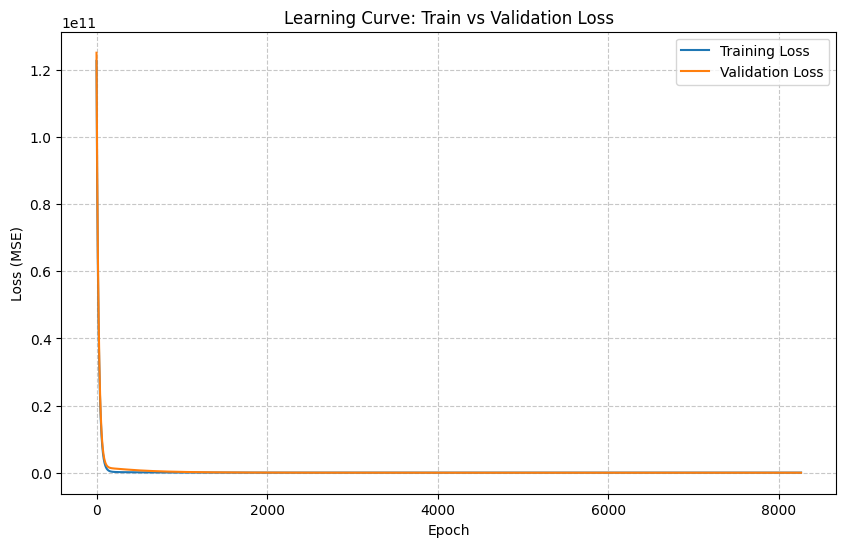

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(train_loss_history, label='Training Loss')
plt.plot(val_loss_history, label='Validation Loss')
plt.title('Learning Curve: Train vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
model.eval() # Chuyển mô hình sang chế độ đánh giá
with torch.no_grad():
    y_test_pred = model(X_test_tensor)
    test_loss = criterion(y_test_pred, y_test_tensor)
    print(f'Sai số (MSE) trên tập kiểm tra: {test_loss.item():.4f}')

    # In thử giá trị dự đoán vs thực tế
    for i in range(len(y_test)):
        print(f"Thực tế: {y_test[i]:.2f} - Dự đoán: {y_test_pred[i].item():.2f}")

Sai số (MSE) trên tập kiểm tra: 35055600.0000
Thực tế: 272500.00 - Dự đoán: 271302.03
Thực tế: 280000.00 - Dự đoán: 282191.31
Thực tế: 475000.00 - Dự đoán: 479313.81
Thực tế: 499000.00 - Dự đoán: 498397.38
Thực tế: 305000.00 - Dự đoán: 316410.97
Thực tế: 385000.00 - Dự đoán: 374257.19
Thực tế: 300000.00 - Dự đoán: 303087.00
Thực tế: 292000.00 - Dự đoán: 291703.56
